# Processing Images for Neural Networks


## From Inverse Problems to Neural Imaging Pipelines

Before introducing **PyTorch** itself, it is useful to make one intermediate step explicit. In the first module of the course, image reconstruction was formulated as the inverse problem

$$
\boldsymbol{y}^\delta = K\boldsymbol{x}^* + \boldsymbol{e},
$$

where $K \in \mathbb{R}^{m \times n}$ is the discrete acquisition operator, $\boldsymbol{x}^* \in \mathbb{R}^n$ is the unknown image, and $\boldsymbol{e} \in \mathbb{R}^m$ models noise and perturbation. Classical reconstruction methods then compute an approximation of $\boldsymbol{x}^*$ by solving a variational problem of the form

$$
\hat{\boldsymbol{x}} = \operatorname*{arg\,min}_{\boldsymbol{x}} \Big( \mathcal{D}(K\boldsymbol{x},\boldsymbol{y}^\delta) + \mathcal{R}(\boldsymbol{x}) \Big).
$$

When neural networks enter the picture, this mathematical structure is not discarded. Rather, it is re-expressed in a form that is compatible with tensor computation, stochastic optimization, and large datasets. The purpose of the present chapter is therefore to explain how an imaging problem moves from the language of vectors and operators to the language of **batches**, **channels**, **datasets**, and **data loaders**.

```{note}
A useful teaching point is that data preparation is not a secondary implementation step. The way one stores images, normalizes intensities, and batches samples already encodes assumptions on the reconstruction problem and on the class of admissible solutions.
```


**End-to-end and hybrid strategies.**

A first conceptual distinction concerns the role played by the network inside the reconstruction method.

In an **end-to-end reconstruction** strategy, one trains a model $f_{\boldsymbol{\Theta}}$ that maps the measured datum directly to a reconstructed image,

$$
\hat{\boldsymbol{x}} = f_{\boldsymbol{\Theta}}(\boldsymbol{y}^\delta).
$$

This approach is attractive because inference is fast once training is completed: a single forward pass can replace a long iterative algorithm. The difficulty is that the network is asked to absorb, within one learned map, both the geometry of the acquisition process and the prior structure of the image class.

```{image} /imgs/end-to-end.png
:width: 95%
:align: center
```

In a **hybrid method**, by contrast, one retains an explicit reconstruction step based on the physics or on a classical solver, and uses the neural network only as one part of the full method. The network may act as a learned regularizer, a denoiser, a post-processing operator, or a module inside an iterative scheme. This is computationally more expensive, but it often gives stronger control over **data consistency** and over the relation between the reconstruction and the measurement model.

```{image} /imgs/hybrid-approach.png
:width: 95%
:align: center
```


## Representing and Preparing Images for Neural Networks

Classical inverse-problem notation often treats images as vectors in $\mathbb{R}^n$. This is mathematically convenient, but it hides the spatial structure of the data. Neural networks, and especially convolutional models, are designed precisely to exploit this structure. For this reason, images are not usually flattened before entering the model.

Instead, a grayscale image is represented as a tensor of shape

$$
(C,H,W),
$$

with $C=1$, while a minibatch of $B$ grayscale images is represented as

$$
(B,C,H,W).
$$

For RGB images one has $C=3$. For multispectral or physically richer measurements, the channel dimension may carry additional information. The crucial point is that the tensor representation preserves the two-dimensional geometry of the image.

This has an immediate consequence for the operator notation. If one works with batches, the forward operator must be understood as acting on structured tensors rather than on isolated vectors. In practice, one should think of a map of the form

$$
K : \mathbb{R}^{B \times C \times H \times W} \to \mathbb{R}^{B \times C' \times H' \times W'}.
$$

This is one reason why it is often misleading to think of the computational operator as a literal dense matrix. In realistic imaging problems, $K$ is implemented as an algorithmic operator, and when needed its transpose or adjoint is represented computationally through a companion map $K^T$.

```{warning}
In neural imaging pipelines, shape conventions are part of the mathematical model. A tensor of shape $(H,W)$ and a tensor of shape $(1,1,H,W)$ may represent the same image visually, but they do not play the same role inside a network.
```


In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "course_utils.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from course_utils import gray, rgb, show


Original dtype: uint8
Normalized range: 0.0 0.8627451062202454
Single image tensor shape (C,H,W): (1, 256, 256)
Batched tensor shape (B,C,H,W): (1, 1, 256, 256)
Mini-batch of three images: (3, 1, 256, 256)


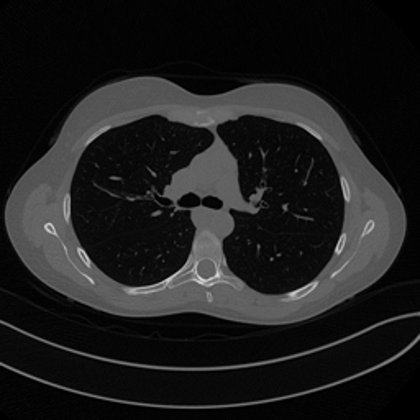

In [2]:
import numpy as np
import torch

img = gray("Mayo.png", size=256)
array_uint8 = np.asarray(img, dtype=np.uint8)
array_float = np.asarray(img, dtype=np.float32) / 255.0

single_image = torch.tensor(array_float).unsqueeze(0)
batched_image = single_image.unsqueeze(0)
stacked_batch = torch.stack([single_image, single_image.flip(-1), single_image.flip(-2)], dim=0)

print('Original dtype:', array_uint8.dtype)
print('Normalized range:', float(array_float.min()), float(array_float.max()))
print('Single image tensor shape (C,H,W):', tuple(single_image.shape))
print('Batched tensor shape (B,C,H,W):', tuple(batched_image.shape))
print('Mini-batch of three images:', tuple(stacked_batch.shape))

show(img, width=420)


**Normalization and data type.**

Two preprocessing choices are especially important.

The first is **normalization**. Images stored as `uint8` typically take values in $\{0,\ldots,255\}$. Neural networks are rarely trained directly on this scale. Instead, one usually rescales the data, for example into $[0,1]$, so that activations and gradients remain in numerically stable ranges. This is not merely cosmetic. The scale of the input changes the scale of the loss, and therefore changes the optimization dynamics.

The second is the **data type**. In most imaging applications, `float32` is the standard compromise between memory usage and numerical precision. Lower precision can be faster, but may be too crude for delicate inverse problems. Higher precision can be useful for debugging, operator verification, or especially unstable pipelines, but it increases memory cost significantly.

A third practical point concerns **dataset organization**. Classical deterministic reconstruction methods may process one image at a time. Neural training, by contrast, relies on many samples, often shuffled and batched. The dataset is therefore not an accessory to the model. It is part of the computational definition of the learning problem.


## Datasets, DataLoaders, and a Mayo-Style Example

Once images are stored in a tensor-compatible format, one still needs a mechanism to serve them efficiently during training. In **PyTorch**, this is the role of the `Dataset` and `DataLoader` abstractions.

A **dataset** defines how a single sample is retrieved. It may read an image from disk, normalize it, apply a crop, convert it to a tensor, and return either the clean image, the corrupted measurement, or both. A **data loader** then wraps the dataset and produces shuffled minibatches.

For a course on computational imaging, this distinction is pedagogically important. The dataset is where the acquisition model, the train-test split, and the preprocessing pipeline are encoded. The data loader is where these samples are organized into the batches seen by stochastic optimization.

For this example we will consider an example which we will use multiple time throughout this module: the **Mayo's dataset**. The Mayo's dataset is a commonly-used dataset for benchmarking algorithms for Computed Tomography (CT) image reconstruction from sparse measurement. It can be downloaded from the following link: [Mayo's Dataset Download](https://drive.google.com/drive/folders/13BEiz6t57qSbwBpCtfqllmYTLmkhQeFE?usp=share_link). 

This dataset comprises a total of $N = 3305$ training images and $N = 327$ test images, representing the CT scan of 10 human chests.


In [3]:
import glob

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
import numpy as np

class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()

        self.data_path = data_path
        self.data_shape = data_shape

        # We expect data_path to be like "./data/Mayo/train" or "./data/Mayo/test"
        self.fname_list = glob.glob(f"{data_path}/*/*.png")

    def __len__(self):
        return len(self.fname_list)
    
    def __getitem__(self, idx):
        # Load the idx's image from fname_list
        img_path = self.fname_list[idx]

         # To load the image as grey-scale
        x = Image.open(img_path).convert("L")

        # Resize to the required shape
        x = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(self.data_shape), # (1, n_x, n_y)
        ])(x)
        return x

    def get_patient_and_slice(self, idx):
        """
        A utility function. Given an idx, it returns the patient ID and the number of slice of
        that patient corresponding to the idx's datapoint.
        """
        fname = self.fname_list[idx]
        patient_id = fname.split('/')[-2]
        slice_n = fname.split('/')[-1]
        return patient_id, slice_n


dataset = MayoDataset(data_path="../Mayo/train", data_shape=256)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(loader))
print('Number of patches in the dataset:', len(dataset))
print('Batch tensor shape:', tuple(batch.shape))
print('Batch dtype:', batch.dtype)
print('Batch intensity range:', float(batch.min()), float(batch.max()))


Number of patches in the dataset: 3306
Batch tensor shape: (4, 1, 256, 256)
Batch dtype: torch.float32
Batch intensity range: 0.0 0.9259803295135498


## Exercises

1. Explain why representing an image as a tensor of shape $(B,C,H,W)$ is more natural for neural networks than flattening it immediately into a vector.
2. In the measurement model $\boldsymbol{y}^\delta = K\boldsymbol{x}^\dagger + \boldsymbol{e}$, discuss which parts of the problem may already be affected by preprocessing choices such as normalization or cropping.
3. Compare **end-to-end reconstruction** and **hybrid reconstruction** from the viewpoint of speed, interpretability, and control of data consistency.
4. Suppose a dataset contains grayscale images saved as `uint8`. Describe a mathematically sensible preprocessing pipeline before these images are used for training.
5. Modify the patch dataset example so that each sample returns both a clean patch and a blurred patch produced by a simple fixed kernel.

## Further Reading

The role of data handling in deep learning systems is discussed from a software and systems viewpoint in {cite}`paszke2019pytorch`. For the imaging perspective, the most important follow-up is not a general machine learning text, but the later notebooks of this module, where the same dataset and tensor conventions reappear inside **CNN**, **UNet**, self-supervised, and generative reconstruction pipelines.
